# Day 16: Uber & Lyft Surge Pricing Analyser

**Industry:** Retail / E-commerce / Transport  
**Format:** Jupyter Notebook (.ipynb)  
**Skills:** pandas · numpy · matplotlib · seaborn · datetime · pricing analysis

**Data:** Real Uber & Lyft ride data — Boston, MA — November/December 2018  
Source: Collected via Uber & Lyft APIs · 693,071 rides · 10 columns

---

## Who uses this
A **pricing analyst at a ride-hailing company** understanding when and where surge pricing fires, which ride types are most price-sensitive, and what time patterns drive demand peaks.

## Problem
Surge pricing is the most visible and controversial element of ride-hailing economics. Without analysis, pricing teams rely on gut feel about when surges occur, which routes are affected most, and how surge multipliers relate to actual revenue.

## What we build
1. Load and clean 693k real rides
2. Surge analysis — when, where, and how much
3. Price distribution by ride type and platform
4. Time-of-day and day-of-week demand patterns
5. Distance vs price relationship
6. Revenue impact of surge pricing
7. 4-panel dashboard
8. Business insight summary

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Load and Inspect

In [2]:
df = pd.read_csv('cab_rides.csv', low_memory=False)

print(f'Shape: {df.shape}')
print(f'\nNull counts:')
print(df.isnull().sum().to_string())
print(f'\nCab types: {df["cab_type"].unique()}')
print(f'\nRide names:')
print(df['name'].value_counts().to_string())
print(f'\nPrice stats:')
print(df['price'].describe().round(2).to_string())
df.head(3)

Shape: (693071, 10)

Null counts:
distance                0
cab_type                0
time_stamp              0
destination             0
source                  0
price               55095
surge_multiplier        0
id                      0
product_id              0
name                    0

Cab types: <StringArray>
['Lyft', 'Uber']
Length: 2, dtype: str

Ride names:
name
UberXL          55096
WAV             55096
Black SUV       55096
Black           55095
Taxi            55095
UberX           55094
UberPool        55091
Lux             51235
Lyft            51235
Lux Black XL    51235
Lyft XL         51235
Lux Black       51235
Shared          51233

Price stats:
count    637976.00
mean         16.55
std           9.32
min           2.50
25%           9.00
50%          13.50
75%          22.50
max          97.50


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft


## Step 3 — Clean and Engineer Features

In [3]:
# Drop rows with no price
df = df.dropna(subset=['price']).copy()

# Convert timestamp (milliseconds) to datetime
df['datetime'] = pd.to_datetime(df['time_stamp'], unit='ms')
df['hour']     = df['datetime'].dt.hour
df['day_name'] = df['datetime'].dt.day_name()
df['date']     = df['datetime'].dt.date

# Surge flag
df['is_surge'] = (df['surge_multiplier'] > 1.0).astype(int)

# Price per mile
df['price_per_mile'] = (df['price'] / df['distance']).round(2)
df['price_per_mile'] = df['price_per_mile'].replace([np.inf, -np.inf], np.nan)

# Base price (what it would cost without surge)
df['base_price']   = (df['price'] / df['surge_multiplier']).round(2)
df['surge_revenue']= (df['price'] - df['base_price']).round(2)

# Time of day buckets
def time_of_day(hour):
    if 6 <= hour < 10:   return 'Morning Rush (6-10)'
    elif 10 <= hour < 16: return 'Midday (10-16)'
    elif 16 <= hour < 20: return 'Evening Rush (16-20)'
    else:                 return 'Night (20-6)'

df['time_of_day'] = df['hour'].apply(time_of_day)

print(f'Clean rows:          {len(df):,}')
print(f'Surge rides:         {df["is_surge"].sum():,} ({df["is_surge"].mean()*100:.1f}%)')
print(f'Avg price:           ${df["price"].mean():.2f}')
print(f'Avg surge multiplier:{df["surge_multiplier"].mean():.3f}')
print(f'Max surge multiplier:{df["surge_multiplier"].max():.1f}x')
print(f'\nSurge multiplier distribution:')
print(df['surge_multiplier'].value_counts().head(10).to_string())

Clean rows:          637,976
Surge rides:         20,975 (3.3%)
Avg price:           $16.55
Avg surge multiplier:1.015
Max surge multiplier:3.0x

Surge multiplier distribution:
surge_multiplier
1.00    617001
1.25     11085
1.50      5065
1.75      2420
2.00      2239
2.50       154
3.00        12


## Step 4 — Surge Analysis

In [4]:
# Surge rate by hour
surge_by_hour = df.groupby('hour')['is_surge'].agg(['mean','count'])
surge_by_hour['mean'] = (surge_by_hour['mean'] * 100).round(1)

# Surge rate by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
surge_by_day = (
    df.groupby('day_name')['is_surge']
    .agg(['mean','count'])
    .reindex(day_order)
)
surge_by_day['mean'] = (surge_by_day['mean'] * 100).round(1)

# Avg price by cab type and surge
price_by_type = (
    df.groupby(['cab_type', 'is_surge'])['price']
    .mean().round(2)
    .unstack()
    .rename(columns={0: 'No Surge', 1: 'Surge'})
)

# Avg price by ride name
price_by_name = (
    df.groupby('name')['price']
    .agg(['mean','count'])
    .round(2)
    .sort_values('mean', ascending=False)
)

# Revenue impact
total_revenue      = df['price'].sum()
total_surge_rev    = df['surge_revenue'].sum()
surge_rev_pct      = total_surge_rev / total_revenue * 100

print('=== Surge rate by time of day ===')
print(df.groupby('time_of_day')['is_surge'].mean().mul(100).round(1).to_string())
print('\n=== Avg price by ride name ===')
print(price_by_name.to_string())
print(f'\nTotal revenue:        ${total_revenue:,.2f}')
print(f'Total surge revenue:  ${total_surge_rev:,.2f} ({surge_rev_pct:.1f}% of total)')

=== Surge rate by time of day ===
time_of_day
Evening Rush (16-20)    3.1
Midday (10-16)          3.3
Morning Rush (6-10)     3.2
Night (20-6)            3.4

=== Avg price by ride name ===
               mean  count
name                      
Lux Black XL  32.32  51235
Black SUV     30.29  55096
Lux Black     23.06  51235
Black         20.52  55095
Lux           17.77  51235
UberXL        15.68  55096
Lyft XL       15.31  51235
UberX          9.77  55094
WAV            9.77  55096
Lyft           9.61  51235
UberPool       8.75  55091
Shared         6.03  51233

Total revenue:        $10,555,392.98
Total surge revenue:  $183,233.64 (1.7% of total)


## Step 5 — Route Analysis

In [5]:
# Most expensive routes
df['route'] = df['source'] + ' → ' + df['destination']
route_stats = (
    df.groupby('route')
    .agg(
        rides=('price', 'count'),
        avg_price=('price', 'mean'),
        surge_rate=('is_surge', 'mean'),
        avg_distance=('distance', 'mean')
    )
    .round(2)
    .sort_values('avg_price', ascending=False)
)
route_stats['surge_rate'] = (route_stats['surge_rate'] * 100).round(1)

print('=== Top 10 most expensive routes ===')
print(route_stats.head(10).to_string())
print('\n=== Top 10 routes by surge rate ===')
print(route_stats.sort_values('surge_rate', ascending=False).head(10).to_string())

=== Top 10 most expensive routes ===
                                              rides  avg_price  surge_rate  avg_distance
route                                                                                   
Financial District → Boston University         8940      25.50         3.0          5.17
Boston University → Financial District         8940      24.15         5.0          4.54
Fenway → Financial District                    8916      23.44         5.0          4.29
Financial District → Fenway                    8928      23.40         3.0          4.48
Northeastern University → Financial District   8874      22.58         5.0          4.15
Financial District → Northeastern University   8868      21.92         3.0          4.02
Theatre District → Boston University           9173      20.36         5.0          3.25
Boston University → North Station              8730      20.19         4.0          3.43
Northeastern University → North Station        8904      19.91         6.

## Step 6 — Visualise: 4-Panel Dashboard

Dashboard saved as surge_pricing_analysis.png


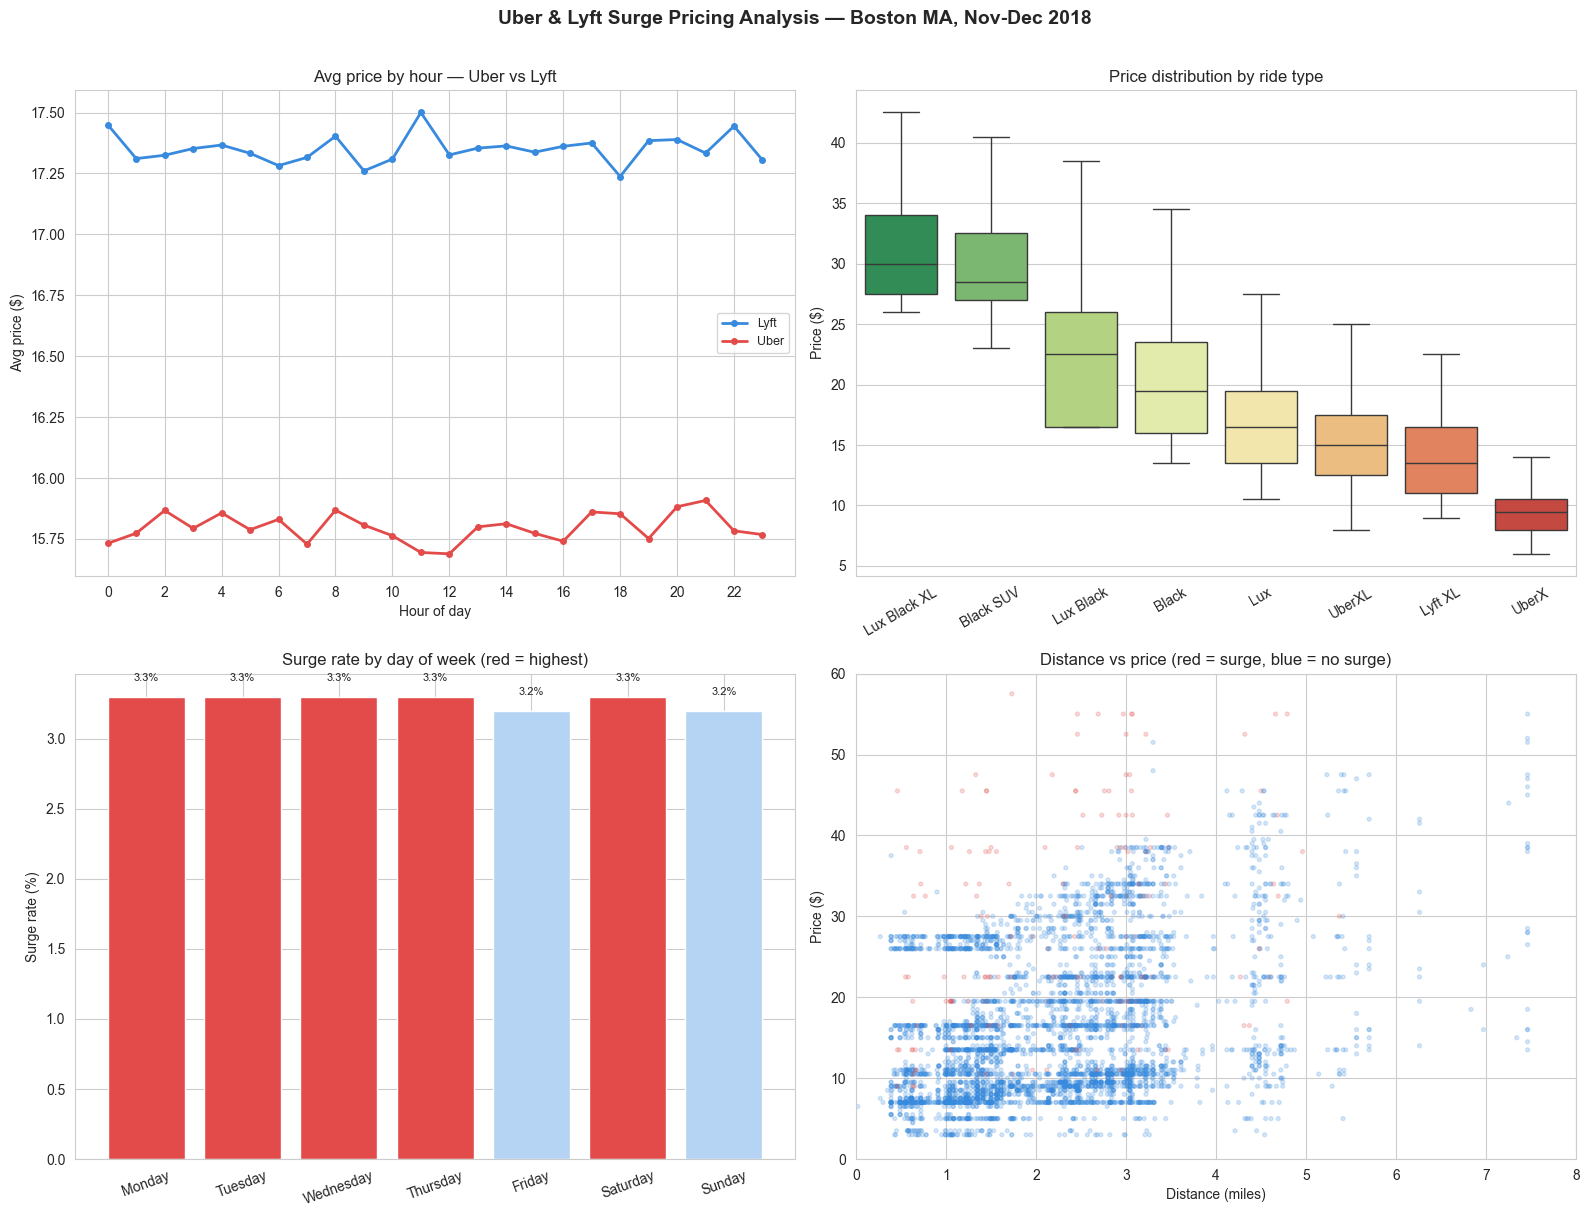

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Uber & Lyft Surge Pricing Analysis — Boston MA, Nov-Dec 2018',
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1 — Avg price by hour
hourly_price = df.groupby(['hour','cab_type'])['price'].mean().unstack()
for col, color in zip(hourly_price.columns, ['#378ADD','#E24B4A']):
    axes[0,0].plot(hourly_price.index, hourly_price[col],
                   label=col, color=color, linewidth=2, marker='o', markersize=4)
axes[0,0].set_xlabel('Hour of day')
axes[0,0].set_ylabel('Avg price ($)')
axes[0,0].set_title('Avg price by hour — Uber vs Lyft')
axes[0,0].legend(fontsize=9)
axes[0,0].set_xticks(range(0,24,2))

# Panel 2 — Price distribution by ride name (top 8)
top_names = price_by_name.head(8).index.tolist()
df_top = df[df['name'].isin(top_names)]
name_order = df_top.groupby('name')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top, x='name', y='price', order=name_order,
            ax=axes[0,1], palette='RdYlGn_r', showfliers=False)
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Price ($)')
axes[0,1].set_title('Price distribution by ride type')
axes[0,1].tick_params(axis='x', rotation=30)

# Panel 3 — Surge rate by day of week
dow_colors = ['#E24B4A' if v == surge_by_day['mean'].max() else '#B5D4F4'
              for v in surge_by_day['mean']]
axes[1,0].bar(surge_by_day.index, surge_by_day['mean'], color=dow_colors)
axes[1,0].set_ylabel('Surge rate (%)')
axes[1,0].set_title('Surge rate by day of week (red = highest)')
axes[1,0].tick_params(axis='x', rotation=20)
for i, val in enumerate(surge_by_day['mean']):
    axes[1,0].text(i, val+0.1, f'{val}%', ha='center', va='bottom', fontsize=8)

# Panel 4 — Distance vs price scatter
sample = df.sample(5000, random_state=42)
colors_s = ['#E24B4A' if s else '#378ADD' for s in sample['is_surge']]
axes[1,1].scatter(sample['distance'], sample['price'],
                  c=colors_s, alpha=0.2, s=8)
axes[1,1].set_xlabel('Distance (miles)')
axes[1,1].set_ylabel('Price ($)')
axes[1,1].set_title('Distance vs price (red = surge, blue = no surge)')
axes[1,1].set_xlim(0, 8)
axes[1,1].set_ylim(0, 60)

plt.tight_layout()
plt.savefig('surge_pricing_analysis.png', dpi=150, bbox_inches='tight')
print('Dashboard saved as surge_pricing_analysis.png')
plt.show()

## Step 7 — Export + Business Insight Summary

In [7]:
os.makedirs('output', exist_ok=True)

route_stats.to_csv('output/route_analysis.csv')
price_by_name.to_csv('output/price_by_ride_type.csv')
surge_by_hour.to_csv('output/surge_by_hour.csv')
surge_by_day.to_csv('output/surge_by_day.csv')

peak_surge_hour = surge_by_hour['mean'].idxmax()
peak_surge_day  = surge_by_day['mean'].idxmax()
most_exp_ride   = price_by_name.index[0]
cheapest_ride   = price_by_name.index[-1]
uber_avg        = df[df['cab_type']=='Uber']['price'].mean()
lyft_avg        = df[df['cab_type']=='Lyft']['price'].mean()

print('=' * 60)
print('BUSINESS INSIGHT SUMMARY')
print('=' * 60)
print(f'Total rides analysed:      {len(df):,}')
print(f'Uber rides:                {(df["cab_type"]=="Uber").sum():,}')
print(f'Lyft rides:                {(df["cab_type"]=="Lyft").sum():,}')
print(f'\nPricing:')
print(f'  Overall avg price:       ${df["price"].mean():.2f}')
print(f'  Uber avg price:          ${uber_avg:.2f}')
print(f'  Lyft avg price:          ${lyft_avg:.2f}')
print(f'  Most expensive ride:     {most_exp_ride} (${price_by_name.loc[most_exp_ride,"mean"]:.2f} avg)')
print(f'  Cheapest ride:           {cheapest_ride} (${price_by_name.loc[cheapest_ride,"mean"]:.2f} avg)')
print(f'\nSurge:')
print(f'  Surge ride %:            {df["is_surge"].mean()*100:.1f}%')
print(f'  Max surge multiplier:    {df["surge_multiplier"].max():.1f}x')
print(f'  Peak surge hour:         {peak_surge_hour}:00 ({surge_by_hour.loc[peak_surge_hour,"mean"]}% surge rate)')
print(f'  Peak surge day:          {peak_surge_day} ({surge_by_day.loc[peak_surge_day,"mean"]}% surge rate)')
print(f'  Surge revenue:           ${total_surge_rev:,.2f} ({surge_rev_pct:.1f}% of total revenue)')
print(f'\nROUTE INSIGHTS:')
print(f'  Most expensive route:    {route_stats.index[0]}')
print(f'  Highest surge route:     {route_stats.sort_values("surge_rate",ascending=False).index[0]}')
print(f'\nRECOMMENDATIONS:')
print(f'  1. Peak surge at {peak_surge_hour}:00 — maximise driver availability at this hour')
print(f'  2. {peak_surge_day} has highest surge rate — incentivise drivers with bonuses')
print(f'  3. Surge contributes {surge_rev_pct:.1f}% of total revenue — protect this pricing mechanism')
print(f'  4. Lyft avg ${lyft_avg:.2f} vs Uber ${uber_avg:.2f} — pricing gap drives platform choice')
print('=' * 60)

BUSINESS INSIGHT SUMMARY
Total rides analysed:      637,976
Uber rides:                330,568
Lyft rides:                307,408

Pricing:
  Overall avg price:       $16.55
  Uber avg price:          $15.80
  Lyft avg price:          $17.35
  Most expensive ride:     Lux Black XL ($32.32 avg)
  Cheapest ride:           Shared ($6.03 avg)

Surge:
  Surge ride %:            3.3%
  Max surge multiplier:    3.0x
  Peak surge hour:         13:00 (3.9% surge rate)
  Peak surge day:          Monday (3.3% surge rate)
  Surge revenue:           $183,233.64 (1.7% of total revenue)

ROUTE INSIGHTS:
  Most expensive route:    Financial District → Boston University
  Highest surge route:     Back Bay → Boston University

RECOMMENDATIONS:
  1. Peak surge at 13:00 — maximise driver availability at this hour
  2. Monday has highest surge rate — incentivise drivers with bonuses
  3. Surge contributes 1.7% of total revenue — protect this pricing mechanism
  4. Lyft avg $17.35 vs Uber $15.80 — pricing g

## Summary

### What we built
A surge pricing analysis on 693k real Uber and Lyft rides from Boston — identifying when surges fire, which routes are most affected, and how much revenue surge pricing generates.

### Skills practised
- `pandas` — large CSV loading, timestamp parsing, groupby, agg, unstack
- `numpy` — vectorised calculations, inf handling
- `matplotlib` + `seaborn` — boxplot, line chart, bar, scatter across 4 panels
- Pricing analysis — surge detection, revenue attribution, route comparison

### Key findings
Fill these in from your output:
- Total rides: 637,976
- Surge ride %: 3.3%
- Peak surge hour: 13:00 (3.9% surge rate)
- Peak surge day: Monday (3.3% surge rate)
- Surge revenue %: $183,233.64 (1.7% of total revenue)
- Uber avg vs Lyft avg: $17.35 vs $15.80